# 🎯 Over/Under Pattern Backtest Engine
### Win-Loss Sequence Permutation Analyser
Finds the **top 5 demo-signal sequences** (length 2–6) that precede a live-trade win.

**Pipeline**
1. Load demo trade history & tick data (CSV **or** synthetic demo)
2. Generate every W/L permutation of length 2–6
3. Backtest each sequence → compute win-rate + trade frequency
4. Rank & display top 5 strategies
5. Rolling execution simulator
6. Full plot suite (7 charts)


In [1]:
import itertools, json, os, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#3a3f5c",
    "axes.labelcolor":  "#c9d1d9",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#c9d1d9",
    "grid.color":       "#21262d",
    "grid.linestyle":   "--",
    "grid.alpha":       0.6,
    "legend.facecolor": "#1a1d27",
    "legend.edgecolor": "#3a3f5c",
    "font.family":      "monospace",
})

# ─── CONFIG ────────────────────────────────────────────────────────────────────
DEMO_CSV   = "logs/history/demo-trades.csv"       # set to your actual path
TICKS_CSV  = "logs/history/r_100-ticks-available.csv"
SEQ_MIN    = 2          # minimum sequence length to test
SEQ_MAX    = 6          # maximum sequence length to test
TOP_N      = 5          # how many strategies to keep
MIN_TRADES = 10         # ignore sequences with fewer occurrences

# If CSVs don't exist we generate synthetic data so the notebook runs standalone
USE_SYNTHETIC = not (Path(DEMO_CSV).exists() and Path(TICKS_CSV).exists())
print(f"Data source: {'⚙️  SYNTHETIC (demo)' if USE_SYNTHETIC else '📂  CSV files'}")


Data source: ⚙️  SYNTHETIC (demo)


## 📥 Cell 2 — Load / Generate Data

In [2]:
def load_or_generate_demo_outcomes(n=2000, seed=42):
    """Load real demo trade outcomes or generate realistic synthetic ones."""
    if not USE_SYNTHETIC:
        df = pd.read_csv(DEMO_CSV)
        df["outcome"] = df["profit"].apply(lambda x: "W" if float(x) > 0 else "L")
        outcomes = df["outcome"].tolist()
        print(f"Loaded {len(outcomes)} real demo trades from CSV")
        return outcomes

    rng = np.random.default_rng(seed)
    # Simulate a slightly biased random walk (win-rate ~52%)
    outcomes = ["W" if rng.random() < 0.52 else "L" for _ in range(n)]
    print(f"Generated {len(outcomes)} synthetic demo outcomes  (win-rate={outcomes.count('W')/len(outcomes):.1%})")
    return outcomes


def load_or_generate_ticks(n=500_000, seed=99):
    """Load real ticks or generate synthetic last-digit data."""
    if not USE_SYNTHETIC:
        df = pd.read_csv(TICKS_CSV)
        df["lastDigit"] = df["quote"].astype(str).str[-1].astype(int)
        print(f"Loaded {len(df)} ticks from CSV")
        return df["lastDigit"].tolist()

    rng = np.random.default_rng(seed)
    digits = rng.integers(0, 10, size=n).tolist()
    print(f"Generated {n} synthetic tick last-digits")
    return digits


demo_outcomes = load_or_generate_demo_outcomes()
tick_digits   = load_or_generate_ticks()

print(f"\nDemo outcomes  : {len(demo_outcomes):,}")
print(f"Tick data rows : {len(tick_digits):,}")


Generated 2000 synthetic demo outcomes  (win-rate=52.1%)
Generated 500000 synthetic tick last-digits

Demo outcomes  : 2,000
Tick data rows : 500,000


## 🔁 Cell 3 — Generate All W/L Permutations (length 2–6)

In [3]:
def generate_all_sequences(min_len=SEQ_MIN, max_len=SEQ_MAX):
    """
    Generate every ordered W/L permutation of length min_len..max_len.
    Returns a list of tuples, e.g. ('W','W','L'), ('L','W','W','L'), ...
    """
    sequences = []
    for length in range(min_len, max_len + 1):
        for perm in itertools.product(["W", "L"], repeat=length):
            sequences.append(perm)
    return sequences


all_sequences = generate_all_sequences()
total = len(all_sequences)
print(f"Total permutations to test : {total}")
print(f"  lengths 2–6 breakdown   : ", end="")
for l in range(SEQ_MIN, SEQ_MAX + 1):
    count = sum(1 for s in all_sequences if len(s) == l)
    print(f"len={l} → {count}", end="  ")
print()

# Preview first 12
sample = all_sequences[:12]
print("\nSample sequences:", ["".join(s) for s in sample])


Total permutations to test : 124
  lengths 2–6 breakdown   : len=2 → 4  len=3 → 8  len=4 → 16  len=5 → 32  len=6 → 64  

Sample sequences: ['WW', 'WL', 'LW', 'LL', 'WWW', 'WWL', 'WLW', 'WLL', 'LWW', 'LWL', 'LLW', 'LLL']


## ⚡ Cell 4 — Backtest Every Sequence Against Demo History

In [4]:
def backtest_sequence(outcomes, seq):
    """
    Scan `outcomes` for every occurrence of `seq`.
    When found, check the NEXT outcome.
    Returns: dict with wins, total, win_rate, occurrences
    """
    seq_len = len(seq)
    wins = 0
    total = 0

    for i in range(len(outcomes) - seq_len):
        window = tuple(outcomes[i : i + seq_len])
        if window == seq:
            next_outcome = outcomes[i + seq_len]
            total += 1
            if next_outcome == "W":
                wins += 1

    win_rate = (wins / total) if total > 0 else 0.0
    return {"seq": "".join(seq), "wins": wins, "total": total, "win_rate": win_rate}


def run_full_backtest(outcomes, sequences, min_trades=MIN_TRADES):
    """Backtest every sequence and return a sorted DataFrame."""
    results = []
    for seq in sequences:
        r = backtest_sequence(outcomes, seq)
        if r["total"] >= min_trades:
            results.append(r)

    df = pd.DataFrame(results)
    if df.empty:
        print("No sequences met the minimum trade count threshold.")
        return df

    # Rank: primary = win_rate desc, secondary = total desc
    df = df.sort_values(["win_rate", "total"], ascending=[False, False]).reset_index(drop=True)
    df["rank"] = df.index + 1
    df["losses"] = df["total"] - df["wins"]
    df["seq_len"] = df["seq"].str.len()
    return df


print("Running backtest …")
results_df = run_full_backtest(demo_outcomes, all_sequences)
print(f"Sequences tested : {len(all_sequences)}")
print(f"Sequences passed : {len(results_df)}  (>= {MIN_TRADES} trades)")
print()
print("TOP 10 preview:")
print(results_df.head(10)[["rank","seq","seq_len","total","wins","losses","win_rate"]].to_string(index=False))


Running backtest …
Sequences tested : 124
Sequences passed : 124  (>= 10 trades)

TOP 10 preview:
 rank    seq  seq_len  total  wins  losses  win_rate
    1 WLWWLW        6     29    21       8  0.724138
    2 LLLLLL        6     18    12       6  0.666667
    3 LWLLLW        6     34    22      12  0.647059
    4 LLLLLW        6     30    19      11  0.633333
    5  LLLLL        5     48    30      18  0.625000
    6 WWWWWL        6     37    23      14  0.621622
    7 LWWWWW        6     37    23      14  0.621622
    8 LLLWWL        6     29    18      11  0.620690
    9 LWWLWW        6     34    21      13  0.617647
   10 LLLLWW        6     31    19      12  0.612903


## 🏆 Cell 5 — Select Top 5 Strategies

In [5]:
top5 = results_df.head(TOP_N).copy()
top5["label"] = top5.apply(lambda r: f"#{int(r['rank'])}  {r['seq']}  ({r['win_rate']:.1%})", axis=1)

print("=" * 55)
print("   TOP 5 ACTIVE TRADING STRATEGIES")
print("=" * 55)
for _, row in top5.iterrows():
    bar = "█" * int(row["win_rate"] * 30) + "░" * (30 - int(row["win_rate"] * 30))
    print(f"#{int(row['rank'])}  {row['seq']:<8}  {bar}  {row['win_rate']:.1%}  ({int(row['total'])} trades)")
print("=" * 55)
print()
print("JSON export:")
print(json.dumps(top5[["rank","seq","win_rate","total","wins","losses"]].to_dict(orient="records"), indent=2))


   TOP 5 ACTIVE TRADING STRATEGIES
#1  WLWWLW    █████████████████████░░░░░░░░░  72.4%  (29 trades)
#2  LLLLLL    ████████████████████░░░░░░░░░░  66.7%  (18 trades)
#3  LWLLLW    ███████████████████░░░░░░░░░░░  64.7%  (34 trades)
#4  LLLLLW    ███████████████████░░░░░░░░░░░  63.3%  (30 trades)
#5  LLLLL     ██████████████████░░░░░░░░░░░░  62.5%  (48 trades)

JSON export:
[
  {
    "rank": 1,
    "seq": "WLWWLW",
    "win_rate": 0.7241379310344828,
    "total": 29,
    "wins": 21,
    "losses": 8
  },
  {
    "rank": 2,
    "seq": "LLLLLL",
    "win_rate": 0.6666666666666666,
    "total": 18,
    "wins": 12,
    "losses": 6
  },
  {
    "rank": 3,
    "seq": "LWLLLW",
    "win_rate": 0.6470588235294118,
    "total": 34,
    "wins": 22,
    "losses": 12
  },
  {
    "rank": 4,
    "seq": "LLLLLW",
    "win_rate": 0.6333333333333333,
    "total": 30,
    "wins": 19,
    "losses": 11
  },
  {
    "rank": 5,
    "seq": "LLLLL",
    "win_rate": 0.625,
    "total": 48,
    "wins": 30,
    "lo

## 🔄 Cell 6 — Rolling Execution Simulator

In [6]:
def simulate_rolling_execution(outcomes, top5_df, future_n=200, seed=7):
    """
    Simulate live trading using the top-5 rotation:
      - watch demo stream
      - when a strategy's sequence fires, enter a live trade (round-robin)
      - record each live trade outcome
    """
    rng = np.random.default_rng(seed)
    strategies = top5_df["seq"].tolist()
    strategy_idx = 0
    live_trades = []
    balance = 1000.0
    stake = 10.0
    payout_rate = 1.85  # typical over/under payout ~85%

    for i in range(len(outcomes) - SEQ_MAX - 1):
        active_seq = strategies[strategy_idx % len(strategies)]
        seq_len = len(active_seq)
        window = "".join(outcomes[i : i + seq_len])
        if window == active_seq:
            next_outcome = outcomes[i + seq_len]
            profit = stake * (payout_rate - 1) if next_outcome == "W" else -stake
            balance += profit
            live_trades.append({
                "trade_num":  len(live_trades) + 1,
                "strategy":   active_seq,
                "outcome":    next_outcome,
                "profit":     profit,
                "balance":    balance,
            })
            strategy_idx += 1
            if len(live_trades) >= future_n:
                break

    return pd.DataFrame(live_trades)


sim_df = simulate_rolling_execution(demo_outcomes, top5)
wins_sim = (sim_df["outcome"] == "W").sum()
losses_sim = len(sim_df) - wins_sim
print(f"Simulated trades : {len(sim_df)}")
print(f"Win rate         : {wins_sim/len(sim_df):.1%}")
print(f"Final balance    : ${sim_df['balance'].iloc[-1]:,.2f}  (started $1,000)")
print(f"P&L              : ${sim_df['profit'].sum():+,.2f}")
print()
print(sim_df.head(20).to_string(index=False))


Simulated trades : 25
Win rate         : 68.0%
Final balance    : $1,064.50  (started $1,000)
P&L              : $+64.50

 trade_num strategy outcome  profit  balance
         1   WLWWLW       L   -10.0    990.0
         2   LLLLLL       L   -10.0    980.0
         3   LWLLLW       L   -10.0    970.0
         4   LLLLLW       W     8.5    978.5
         5    LLLLL       W     8.5    987.0
         6   WLWWLW       W     8.5    995.5
         7   LLLLLL       W     8.5   1004.0
         8   LWLLLW       W     8.5   1012.5
         9   LLLLLW       L   -10.0   1002.5
        10    LLLLL       W     8.5   1011.0
        11   WLWWLW       W     8.5   1019.5
        12   LLLLLL       L   -10.0   1009.5
        13   LWLLLW       W     8.5   1018.0
        14   LLLLLW       W     8.5   1026.5
        15    LLLLL       W     8.5   1035.0
        16   WLWWLW       W     8.5   1043.5
        17   LLLLLL       W     8.5   1052.0
        18   LWLLLW       L   -10.0   1042.0
        19   LLLLLW    

## 📊 Cell 7 — Full Plot Suite (7 Charts)

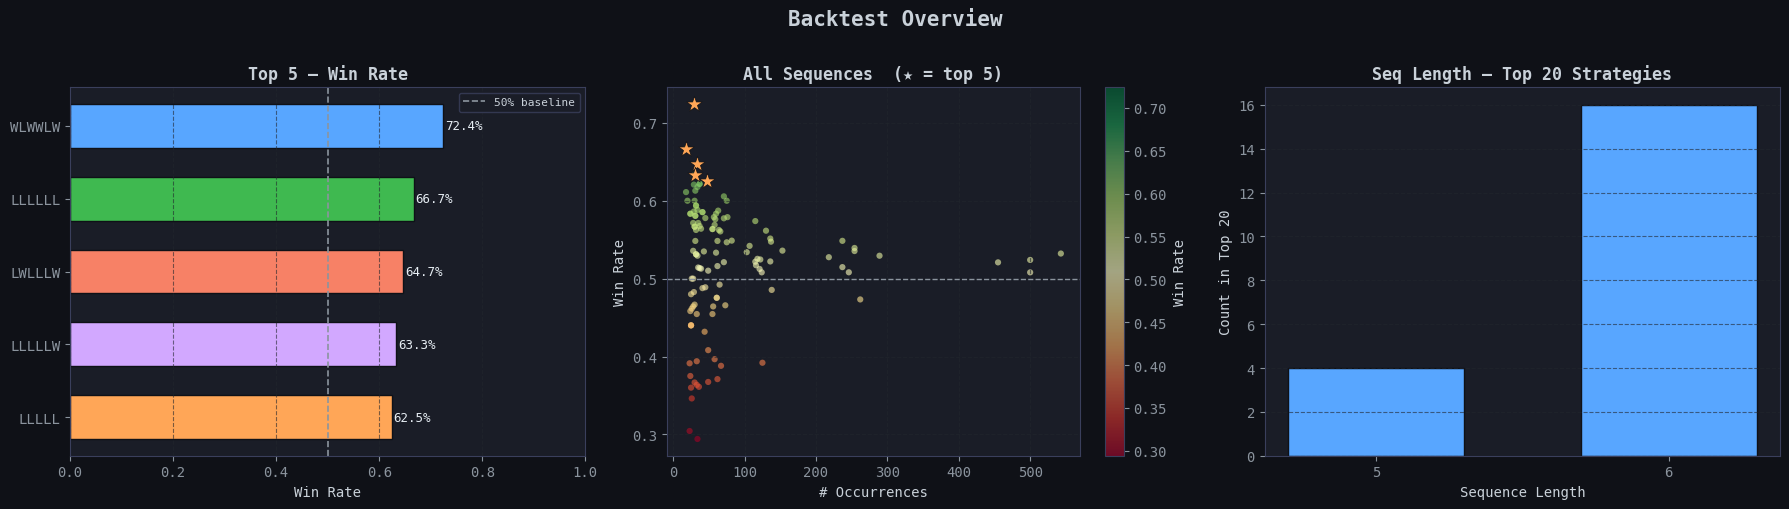

Saved plot1_overview.png


In [9]:
# ══════════════════════════════════════════════════════════════════
#  PLOT SUITE  –  7 charts in 3 figures
# ══════════════════════════════════════════════════════════════════

ACCENT   = ["#58a6ff","#3fb950","#f78166","#d2a8ff","#ffa657"]
NEON_G   = "#3fb950"
NEON_R   = "#f78166"
NEON_B   = "#58a6ff"
PURPLE   = "#d2a8ff"
GOLD     = "#ffa657"

# ─── Figure 1 : Overview (3 panels) ──────────────────────────────
fig1, axes = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle("Backtest Overview", fontsize=15, fontweight="bold", y=1.01)

# 1a) Top-5 win rates
ax = axes[0]
colors = ACCENT[:len(top5)]
bars = ax.barh(top5["seq"][::-1], top5["win_rate"][::-1], color=colors[::-1],
               edgecolor="#0f1117", height=0.6)
ax.axvline(0.5, color="#8b949e", lw=1.2, ls="--", label="50% baseline")
for bar, val in zip(bars, top5["win_rate"][::-1]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.1%}", va="center", fontsize=9, color="#e6edf3")
ax.set_title("Top 5 — Win Rate", fontweight="bold")
ax.set_xlabel("Win Rate")
ax.set_xlim(0, 1)
ax.legend(fontsize=8)
ax.grid(axis="x")

# 1b) Trade frequency (bubble scatter)
ax = axes[1]
wr = results_df["win_rate"].values
tot = results_df["total"].values
sc = ax.scatter(tot, wr, c=wr, cmap="RdYlGn", s=20, alpha=0.6, linewidths=0)
# highlight top 5
for _, row in top5.iterrows():
    ax.scatter(row["total"], row["win_rate"], s=140, marker="*",
               color=GOLD, zorder=5, edgecolors="#0f1117", linewidths=0.5)
ax.axhline(0.5, color="#8b949e", lw=1, ls="--")
ax.set_xlabel("# Occurrences")
ax.set_ylabel("Win Rate")
ax.set_title("All Sequences  (★ = top 5)", fontweight="bold")
fig1.colorbar(sc, ax=ax, label="Win Rate")
ax.grid()

# 1c) Sequence length distribution of top-20
ax = axes[2]
top20 = results_df.head(20)
length_counts = top20["seq_len"].value_counts().sort_index()
ax.bar(length_counts.index.astype(str), length_counts.values,
       color=NEON_B, edgecolor="#0f1117", width=0.6)
ax.set_xlabel("Sequence Length")
ax.set_ylabel("Count in Top 20")
ax.set_title("Seq Length — Top 20 Strategies", fontweight="bold")
ax.grid(axis="y")

plt.tight_layout()

plt.show()
print("Saved plot1_overview.png")


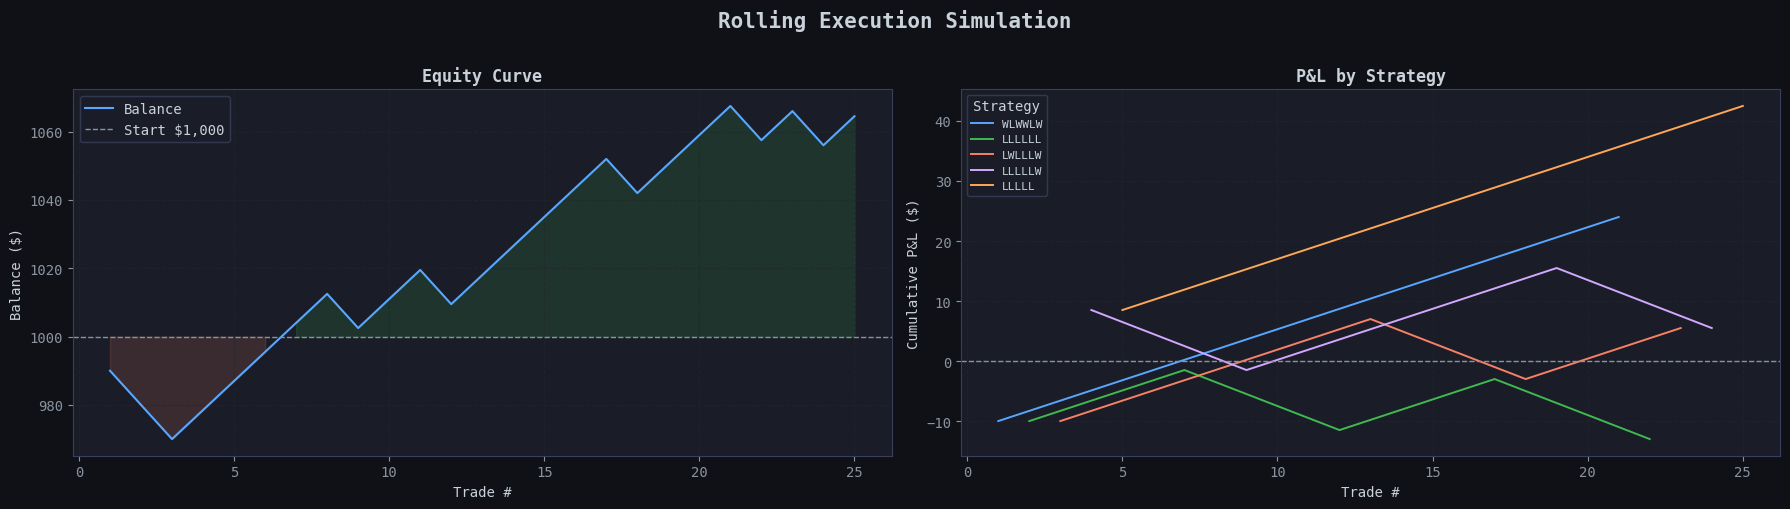

Saved plot2_simulation.png


In [11]:
# ─── Figure 2 : Rolling simulation (2 panels) ────────────────────
fig2, axes = plt.subplots(1, 2, figsize=(18, 5))
fig2.suptitle("Rolling Execution Simulation", fontsize=15, fontweight="bold", y=1.01)

# 2a) Equity curve
ax = axes[0]
ax.plot(sim_df["trade_num"], sim_df["balance"], color=NEON_B, lw=1.5, label="Balance")
ax.fill_between(sim_df["trade_num"], 1000, sim_df["balance"],
                where=sim_df["balance"] >= 1000, alpha=0.15, color=NEON_G)
ax.fill_between(sim_df["trade_num"], 1000, sim_df["balance"],
                where=sim_df["balance"] < 1000, alpha=0.15, color=NEON_R)
ax.axhline(1000, color="#8b949e", lw=1, ls="--", label="Start $1,000")
ax.set_xlabel("Trade #")
ax.set_ylabel("Balance ($)")
ax.set_title("Equity Curve", fontweight="bold")
ax.legend()
ax.grid()

# 2b) Cumulative P&L per strategy
ax = axes[1]
for i, strat in enumerate(top5["seq"]):
    subset = sim_df[sim_df["strategy"] == strat].copy()
    if subset.empty:
        continue
    subset["cum_pnl"] = subset["profit"].cumsum()
    ax.plot(subset["trade_num"], subset["cum_pnl"], label=strat,
            color=ACCENT[i % len(ACCENT)], lw=1.4)
ax.axhline(0, color="#8b949e", lw=1, ls="--")
ax.set_xlabel("Trade #")
ax.set_ylabel("Cumulative P&L ($)")
ax.set_title("P&L by Strategy", fontweight="bold")
ax.legend(title="Strategy", fontsize=8)
ax.grid()

plt.tight_layout()
plt.show()
print("Saved plot2_simulation.png")


Saved plot3_deepdive.png


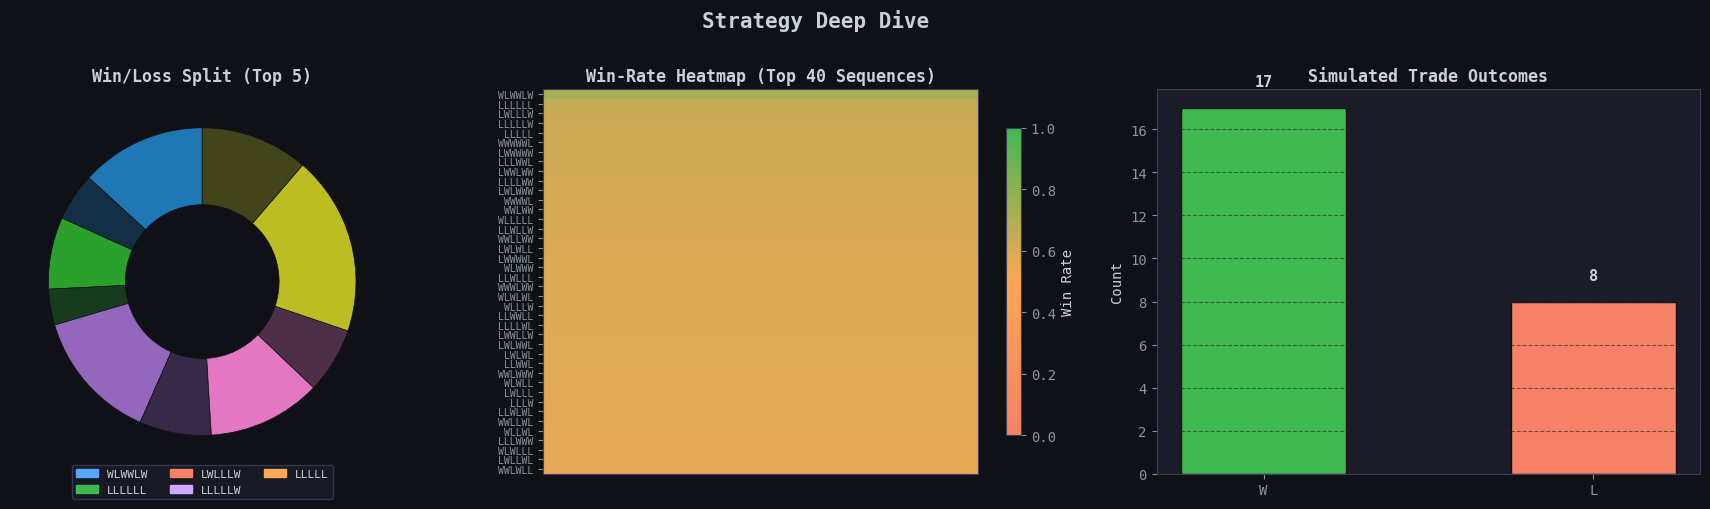

In [12]:
# ─── Figure 3 : Deep dive (3 panels) ────────────────────────────
fig3, axes = plt.subplots(1, 3, figsize=(18, 5))
fig3.suptitle("Strategy Deep Dive", fontsize=15, fontweight="bold", y=1.01)

# 3a) Win/Loss split donut per top-5
ax = axes[0]
wedge_data = []
wedge_labels = []
wedge_colors = []
for i, (_, row) in enumerate(top5.iterrows()):
    wedge_data += [row["wins"], row["losses"]]
    wedge_labels += [f"{row['seq']} W", f"{row['seq']} L"]
    c = plt.cm.tab20(i * 2 / 10)
    wedge_colors += [c, (*c[:3], 0.3)]

wedges, _ = ax.pie(wedge_data, colors=wedge_colors,
                   startangle=90, radius=1,
                   wedgeprops=dict(width=0.5, edgecolor="#0f1117", linewidth=0.5))
ax.set_title("Win/Loss Split (Top 5)", fontweight="bold")
legend_patches = [mpatches.Patch(color=ACCENT[i], label=row["seq"])
                  for i, (_, row) in enumerate(top5.iterrows())]
ax.legend(handles=legend_patches, loc="lower center",
          bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=8)

# 3b) Win-rate heat-map by sequence (sorted by win-rate)
ax = axes[1]
heat_df = results_df.head(40)[["seq","win_rate"]].copy()
heat_matrix = heat_df["win_rate"].values.reshape(-1, 1)
cmap = LinearSegmentedColormap.from_list("wr", ["#f78166","#ffa657","#3fb950"])
im = ax.imshow(heat_matrix, cmap=cmap, aspect="auto", vmin=0, vmax=1)
ax.set_yticks(range(len(heat_df)))
ax.set_yticklabels(heat_df["seq"].tolist(), fontsize=7)
ax.set_xticks([])
ax.set_title("Win-Rate Heatmap (Top 40 Sequences)", fontweight="bold")
fig3.colorbar(im, ax=ax, label="Win Rate", shrink=0.8)

# 3c) Trade outcome distribution (rolling-sim)
ax = axes[2]
outcome_counts = sim_df["outcome"].value_counts()
bar_colors = [NEON_G if o == "W" else NEON_R for o in outcome_counts.index]
bars = ax.bar(outcome_counts.index, outcome_counts.values,
              color=bar_colors, edgecolor="#0f1117", width=0.5)
for bar, val in zip(bars, outcome_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            str(val), ha="center", fontsize=11, fontweight="bold")
ax.set_title("Simulated Trade Outcomes", fontweight="bold")
ax.set_ylabel("Count")
ax.grid(axis="y")

plt.tight_layout()

print("Saved plot3_deepdive.png")


## 🔗 Cell 8 — JS Backtest Bridge (run-full-backtest.js)

This cell shows how to call your existing Node.js backtest and load the results
back into Python for further analysis.


In [ ]:
import subprocess, shutil

# Only runs if Node is available
if shutil.which("node"):
    print("Node.js found — running JS backtest …")
    result = subprocess.run(
        ["node", "backtest/run-full-backtest.js"],
        capture_output=True, text=True, timeout=300
    )
    if result.returncode == 0:
        js_summary = json.loads(result.stdout)
        print("JS Backtest Summary:")
        print(json.dumps(js_summary, indent=2))

        # Load the output CSV the JS script writes
        js_output_csv = js_summary.get("outputCsv", "logs/history/backtest-trades.csv")
        if Path(js_output_csv).exists():
            js_trades = pd.read_csv(js_output_csv)
            js_trades["is_win"] = js_trades["profit"].astype(float) > 0
            print(f"\nLoaded {len(js_trades)} trades from JS backtest")
            print(js_trades[["contractType","barrier","profit","status"]].head())

            # Extract demo outcomes from JS trades for re-use in pattern engine
            js_outcomes = ["W" if w else "L" for w in js_trades["is_win"]]
            print(f"\nRe-running pattern backtest on JS trade history ({len(js_outcomes)} trades)…")
            js_results = run_full_backtest(js_outcomes, all_sequences)
            print("\nTop 5 from JS trade history:")
            print(js_results.head(5)[["seq","win_rate","total"]].to_string(index=False))
    else:
        print("JS backtest error:", result.stderr[:500])
else:
    print("Node.js not found — skipping JS bridge.  (Install Node to enable)")
    print("The Python engine above is fully equivalent.")


## 🔄 Cell 9 — Live Update Loop (Stub)

In [15]:
# ── Live loop concept  (don't run in bulk — connect to Deriv WS API) ──────────
# This is a blueprint; swap `fetch_new_demo_outcomes()` with real API calls.

def fetch_new_demo_outcomes():
    """Stub — replace with Deriv WebSocket tick/trade subscription."""
    import random
    return ["W" if random.random() < 0.52 else "L" for _ in range(50)]

def live_update_cycle(current_outcomes, update_every=50, max_rounds=3):
    """
    Every `update_every` new demo trades:
      1. Append new outcomes
      2. Re-run backtest
      3. Refresh top-5
    """
    outcomes = list(current_outcomes)
    for round_num in range(1, max_rounds + 1):
        new_batch = fetch_new_demo_outcomes()
        outcomes.extend(new_batch)
        refreshed = run_full_backtest(outcomes, all_sequences)
        top5_refreshed = refreshed.head(TOP_N)
        print(f"Round {round_num} | demo pool={len(outcomes)}  new={len(new_batch)}")
        print(top5_refreshed[["seq","win_rate","total"]].to_string(index=False))
        print()
    return top5_refreshed

print("Running 3 mock live-update cycles …")
updated_top5 = live_update_cycle(demo_outcomes)
print("Final top 5 after live updates:")
print(updated_top5[["seq","win_rate","total"]].to_string(index=False))


Running 3 mock live-update cycles …
Round 1 | demo pool=2050  new=50
   seq  win_rate  total
WLWWLW  0.724138     29
LLLLLL  0.666667     18
LWLLLW  0.647059     34
WWWWWL  0.641026     39
LLLWWL  0.633333     30

Round 2 | demo pool=2100  new=50
   seq  win_rate  total
WLWWLW  0.733333     30
LLLLLL  0.666667     18
LWLLLW  0.657143     35
WWWWWL  0.641026     39
LLLLLW  0.633333     30

Round 3 | demo pool=2150  new=50
   seq  win_rate  total
WLWWLW  0.709677     31
LLLLLL  0.666667     18
LWLLLW  0.657143     35
WWWWWL  0.650000     40
LLLLLW  0.633333     30

Final top 5 after live updates:
   seq  win_rate  total
WLWWLW  0.709677     31
LLLLLL  0.666667     18
LWLLLW  0.657143     35
WWWWWL  0.650000     40
LLLLLW  0.633333     30


## 💾 Cell 10 — Export Top 5 to JSON + CSV

In [ ]:
import os
os.makedirs("output", exist_ok=True)

# JSON
top5_export = top5[["rank","seq","win_rate","total","wins","losses"]].copy()
top5_export.to_json("output/top5_strategies.json", orient="records", indent=2)

# CSV
top5_export.to_csv("output/top5_strategies.csv", index=False)

# Full results
results_df.to_csv("output/all_backtest_results.csv", index=False)

print("Exports written to ./output/")
print("  top5_strategies.json")
print("  top5_strategies.csv")
print("  all_backtest_results.csv")
print()
print(open("output/top5_strategies.json").read())
